In [22]:
# inport
import pandas as pd
import argparse
import numpy as np
import seaborn as sns
import scipy as sc

In [4]:
def get_peaks(data,bin_size_kb=2, comp_flanksize_kb=50, fold_thresh=5):
    scaff_l = list(set(data.Scaffold))
    peak = []
    nopeak = []
    
    for scaff in scaff_l:
        onekbfile = data.loc[data.Scaffold==scaff].reset_index()
        
        for i, bin in onekbfile.iterrows():
            #print(i)
            #print(scaff)
            #print(bin.Start_bp)
            #print(onekbfile)
            #print(onekbfile.iloc[i:i+bin_size_kb-1])
            peak_mean_rho = onekbfile.iloc[i:i+bin_size_kb-1].Rho_kb.mean()
            #print(peak_mean_rho)

            if i == onekbfile.index.max():
                peak_end = onekbfile.iloc[i,].End_bp
            else:
                try:
                    peak_end = onekbfile.iloc[i+1,].End_bp
                except IndexError:
                    #print(onekbfile.index.max())
                    #print(i)
                    #print(bin)
                    peak_end = onekbfile.iloc[i,].End_bp
                    raise IndexError
                    
                    
            flank_start = i-50
            if flank_start<0: # make sure we dont overshoot the scaffold boundary
                flank_start=0
    
            flank_stop = i+bin_size_kb-1+50
            if flank_stop>onekbfile.index.max(): # make sure we dont overshoot the scaffold boundary
                flank_stop=onekbfile.index.max()

            flank_mean_rho = onekbfile.iloc[flank_start:flank_stop].Rho_kb.mean()
            #print(scaff)
            #print(bin.Start_bp)
            #print(peak_end)
            #print(peak_mean_rho)
            #print(flank_mean_rho)
            #print(peak_mean_rho/flank_mean_rho)
            fold_diff = (peak_mean_rho/flank_mean_rho)
            if fold_diff>fold_thresh:
                #print("PEAK")
                peak.append([scaff, bin.Start_bp, peak_end, True, fold_diff, peak_mean_rho, flank_mean_rho])
            else:
                nopeak.append([scaff, bin.Start_bp, peak_end, False, fold_diff, peak_mean_rho, flank_mean_rho])
        #    else: 
        #        peak.append('False')
    return peak, nopeak
        
    

In [5]:
data = pd.read_csv("../data/concat_Mbel_excl5scaff_rmind_hardfilt_exhet_biall_dp_qfilt_mac2_maxmiss06_phimp_LDhat_bpen1_statres_100N_filtMQ70depth2stdev.txt_w1kb", sep='\t')

In [6]:
p, pn = get_peaks(data=data)

In [7]:
peaks = pd.DataFrame(p)
nopeaks = pd.DataFrame(pn)

In [8]:
peaks.columns = ["scaffold", "bin_Start_bp", "bin_Stop_bp", "peak", "fold_diff", "peak_mean_rho", "flank_mean_rho"]
nopeaks.columns = ["scaffold", "bin_Start_bp", "bin_Stop_bp", "peak", "fold_diff", "peak_mean_rho", "flank_mean_rho"]

In [9]:
peaks.bin_Start_bp = peaks.bin_Start_bp.astype(int)#.astype(str)
peaks.bin_Stop_bp = peaks.bin_Stop_bp.astype(int)#.astype(str)
nopeaks.bin_Start_bp = nopeaks.bin_Start_bp.astype(int)#.astype(str)
nopeaks.bin_Stop_bp = nopeaks.bin_Stop_bp.astype(int)#.astype(str)

In [15]:
nopeaks.columns = ['scaffold', 'bin_Start_bp', 'bin_Stop_bp', 'peak', 'fold_diff',
       'peak_mean_rho', 'flank_mean_rho']

In [16]:
allpeaks = pd.concat([peaks, nopeaks])

In [17]:
allpeaks

,scaffold,bin_Start_bp,bin_Stop_bp,peak,fold_diff,peak_mean_rho,flank_mean_rho
0,scaffold84,158000,160000,True,15.618021,22.3870,1.433408
1,scaffold84,159000,161000,True,15.917785,22.6075,1.420267
2,scaffold84,225000,227000,True,6.877480,10.1009,1.468692
3,scaffold84,246000,248000,True,12.109455,22.7223,1.876410
4,scaffold84,294000,296000,True,7.228368,12.9915,1.797294
...,...,...,...,...,...,...,...
1090038,scaffold176,101000,103000,False,0.782028,101.3580,129.609140
1090039,scaffold176,102000,104000,False,1.127683,146.1580,129.609140
1090040,scaffold176,103000,105000,False,1.431442,185.5280,129.609140
1090041,scaffold176,104000,106000,False,1.432484,185.6630,129.609140


In [18]:
kb2_CPG = pd.read_csv('../data/Mbel_cpg_oe_2kbwin.csv', index_col=0)

In [21]:
kb2_CPG_HS = kb2_CPG.merge(allpeaks, left_on=['scaffold', 'start'], right_on=['scaffold','bin_Start_bp'])

In [23]:
kb2_CPG_HS

,scaffold,cpg_oe,start,stop,bin_Start_bp,bin_Stop_bp,peak,fold_diff,peak_mean_rho,flank_mean_rho
0,scaffold1,0.267123,202000.0,204000.0,202000,204000,False,0.029715,0.011192,0.376630
1,scaffold1,0.737826,204000.0,206000.0,204000,206000,False,0.027916,0.010706,0.383505
2,scaffold1,0.632704,206000.0,208000.0,206000,208000,False,0.039299,0.015145,0.385391
3,scaffold1,0.889005,208000.0,210000.0,208000,210000,False,0.055489,0.020699,0.373029
4,scaffold1,0.854450,210000.0,212000.0,210000,212000,False,1.719459,0.622630,0.362108
...,...,...,...,...,...,...,...,...,...,...
564684,scaffold99,0.781708,1786000.0,1788000.0,1786000,1788000,False,0.356448,0.639840,1.795044
564685,scaffold99,0.902772,1788000.0,1790000.0,1788000,1790000,False,0.347525,0.639840,1.841132
564686,scaffold99,0.861702,1790000.0,1792000.0,1790000,1792000,False,0.335381,0.639840,1.907803
564687,scaffold99,0.865554,1792000.0,1794000.0,1792000,1794000,False,0.324845,0.643042,1.979536


<Axes: xlabel='peak', ylabel='cpg_oe'>

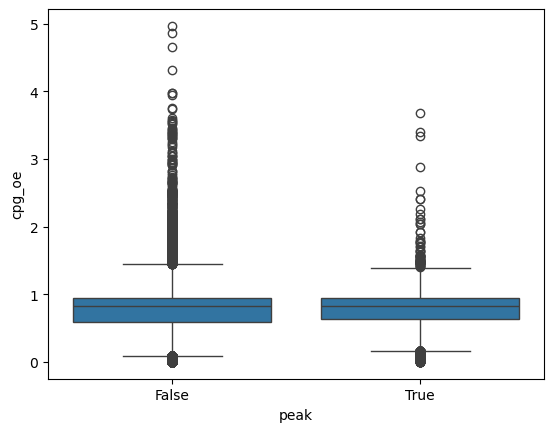

In [24]:
sns.boxplot(x='peak', y='cpg_oe', data=kb2_CPG_HS)

In [26]:
sc.stats.ttest_ind(a=kb2_CPG_HS.loc[kb2_CPG_HS.peak==True].cpg_oe, b=kb2_CPG_HS.loc[kb2_CPG_HS.peak==False].cpg_oe, nan_policy='omit')

TtestResult(statistic=6.507086143886809, pvalue=7.66861680789395e-11, df=564652.0)

In [27]:
kb2_CPG_HS.loc[kb2_CPG_HS.peak==True].cpg_oe.mean()

0.7547024809366627

In [28]:
kb2_CPG_HS.loc[kb2_CPG_HS.peak==False].cpg_oe.mean()

0.741271830416442